# CSE 4095 — Class 4: Comparing Models Fairly
Use AI to help design and implement the workflow, but you must control the comparison.

## 1. Choose your track
Choose classification (`high_exam_score`) or regression (`exam_score`). Write your prediction scenario.

I'm trying to predict whether a student gets a high exam score (80 or above) based on their habits and background. It's a classification problem because the answer is a category (Yes/No), not a number. About 60.4% of students are "No" and 39.6% are "Yes," so it's not perfectly balanced but close enough to work with. Still, a model that always guessed "No" would already be right about 60% of the time.

In [ ]:
import pandas as pd

# keep_default_na=False keeps the text category 'None' as a valid value
df = pd.read_csv(
    '../assignment7/class1_student_habits.csv',
    keep_default_na=False,
    na_values=['']
)

# Classification target: Yes for exam scores of 80 or above
df['high_exam_score'] = df['exam_score'].ge(80).map({True: 'Yes', False: 'No'})

class_percentages = (
    df['high_exam_score']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .round(1)
)

print('Class percentages:')
display(class_percentages.to_frame())


Class percentages:


,percentage
high_exam_score,
No,60.4
Yes,39.6


In [2]:
print(df.isna().sum())
print(f"\nexam_score missing values: {df['exam_score'].isna().sum()}")


student_id                       0
study_hours_per_week             9
sleep_hours_per_night           12
attendance_rate                  0
practice_problems_per_week       0
prior_programming_experience     7
study_group                      0
commute_minutes                  0
quiz_average                     0
exam_score                       0
high_exam_score                  0
dtype: int64

exam_score missing values: 0


## 2. Define X and y
Use legitimate features. Explain excluded columns.

exam_score is what the target is built from (Yes if it's 80+), so using it as a feature would basically hand the model the answer. It would look good on paper but be useless for predicting a student's result ahead of time. I also left out student_id since it's just a label, and quiz_average so the model sticks to habit and background features.

In [3]:
feature_columns = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'prior_programming_experience',
    'study_group',
    'commute_minutes'
]

X = df[feature_columns]
y = df['high_exam_score']

print('X shape:', X.shape)
print('y shape:', y.shape)
display(X.head())


X shape: (250, 7)
y shape: (250,)


,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes
0,1.3,7.7,71.8,8,Strong,No,0
1,9.4,6.6,74.2,14,None,Yes,52
2,11.2,6.1,70.3,15,Some,No,7
3,10.8,7.6,77.1,16,Strong,No,12
4,8.0,5.6,89.7,15,None,Yes,12


## 3. Train/test split
Create an 80/20 split. Keep the test set for final evaluation.

I'm holding out 20% (50 students) so I have data the model never saw while I was making decisions. If I kept checking test accuracy while changing models, I'd end up picking whatever happens to do well on those 50 students. Then the final score would look better than it really is on new data.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set: {X_test.shape[0]} rows')
print('\nTraining class percentages:')
display((y_train.value_counts(normalize=True) * 100).round(1).rename('percentage').to_frame())
print('Test class percentages:')
display((y_test.value_counts(normalize=True) * 100).round(1).rename('percentage').to_frame())


Training set: 200 rows
Test set: 50 rows

Training class percentages:


,percentage
high_exam_score,
No,60.5
Yes,39.5


Test class percentages:


,percentage
high_exam_score,
No,60.0
Yes,40.0


## 4. Baseline
Create a majority-class baseline for classification or mean baseline for regression.

The baseline just predicts the most common class in the training data ("No") for every student, so it never predicts "Yes." Its mean CV accuracy is 0.605 with a std of 0.010, so it's right about 60% of the time with almost no variation between folds. Any real model should beat that, otherwise it isn't learning anything useful from the features.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline = DummyClassifier(strategy='most_frequent')
baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring='accuracy'
)

print(f'Baseline 5-fold CV accuracy: {baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}')
print('Fold accuracies:', baseline_scores.round(3))


Baseline 5-fold CV accuracy: 0.605 ± 0.010
Fold accuracies: [0.625 0.6   0.6   0.6   0.6  ]


## 5. Preprocessing pipeline
Handle missing values and categorical variables.

Putting the imputer, scaler, and encoder inside the pipeline means they're only fit on the training data each time. That matters for cross-validation because every fold has its own train/validation split, and preprocessing everything first would leak info from the validation fold (like its medians) into training. Logistic Regression is the one model here that's sensitive to scaling. Decision Trees and Random Forests generally don't need it, since they split on thresholds and the ordering of values stays the same.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'study_hours_per_week',
    'sleep_hours_per_night',
    'attendance_rate',
    'practice_problems_per_week',
    'commute_minutes'
]
categorical_features = ['prior_programming_experience', 'study_group']

numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_preprocessor, numeric_features),
    ('categorical', categorical_preprocessor, categorical_features)
])

print(preprocessor)


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['study_hours_per_week',
                                  'sleep_hours_per_night', 'attendance_rate',
                                  'practice_problems_per_week',
                                  'commute_minutes']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['prior_programming_experience',
                                  'study_group'])])


## 6. Cross-validation comparison
Compare a small set of models using the same folds and metrics.

In 5-fold CV the training data gets split into 5 chunks. The model trains on 4 and gets tested on the 5th, and this rotates until every chunk has been the validation set once, so each model is trained 5 times. That's more informative than a single split because I get 5 scores and can see how much they vary, instead of one number that might be lucky or unlucky. I still keep the test set because I use the CV scores to make my choices, so I need data that played no part in those choices for a final check.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

# One shared set of folds makes the comparison fair.
shared_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Majority baseline': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest (200 trees)': RandomForestClassifier(n_estimators=200, random_state=42)
}

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='Yes', zero_division=0),
    'recall': make_scorer(recall_score, pos_label='Yes', zero_division=0)
}

comparison_rows = []
for name, model in models.items():
    workflow = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_validate(
        workflow, X_train, y_train,
        cv=shared_cv, scoring=scoring
    )
    comparison_rows.append({
        'Model': name,
        'Mean accuracy': scores['test_accuracy'].mean(),
        'Std accuracy': scores['test_accuracy'].std(),
        'Precision (Yes)': scores['test_precision'].mean(),
        'Recall (Yes)': scores['test_recall'].mean()
    })

comparison_table = pd.DataFrame(comparison_rows).set_index('Model')
display(comparison_table.round(3))


,Mean accuracy,Std accuracy,Precision (Yes),Recall (Yes)
Model,,,,
Majority baseline,0.605,0.010,0.000,0.000
Logistic Regression,0.740,0.064,0.728,0.571
Decision Tree (depth=4),0.670,0.040,0.598,0.493
Random Forest (200 trees),0.690,0.072,0.642,0.518


Logistic Regression had the highest mean CV accuracy (0.740), followed by Random Forest (0.690), Decision Tree (0.670), and the baseline (0.605). The gaps between the models are about 0.02-0.07, which is small compared to the fold std (0.04-0.07), so I can't say LR is definitely better than Random Forest, just that it looks best so far. LR also had the highest precision (0.728) and recall (0.571), so all the metrics point to the same model here. Even so, recall under 0.6 means every model misses a lot of the high scorers.

## 7. Tune one hyperparameter
Tune decision-tree max_depth using cross-validation on the training data.

A parameter is something the model learns from the data while training, like which feature and cutoff each split in the fitted tree uses. A hyperparameter is something I choose before training, and max_depth is the example: I decide how many levels the tree is allowed to have, and the model doesn't learn that from the data. Changing max_depth changes how complex the tree can get, but the splits inside it are still learned.

,max_depth,Mean train accuracy,Mean CV accuracy,CV std
0,1,0.661,0.560,0.066
1,2,0.712,0.625,0.057
2,3,0.772,0.610,0.051
3,4,0.826,0.670,0.040
4,6,0.925,0.615,0.056
5,8,0.979,0.620,0.043
6,None,1.000,0.595,0.060


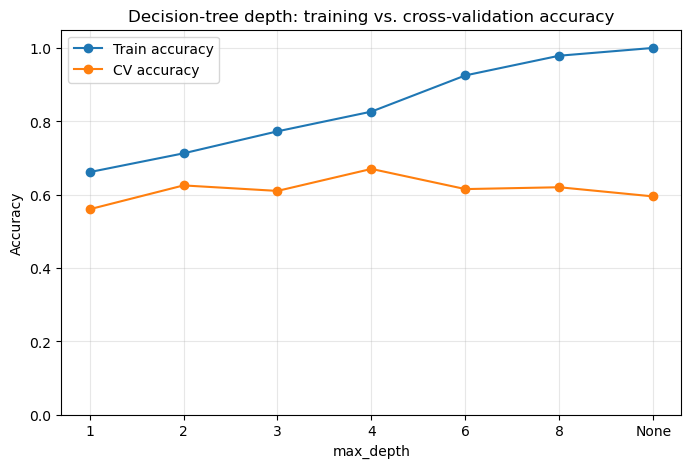

,Mean accuracy,Std accuracy,Precision (Yes),Recall (Yes)
Majority baseline,0.605,0.010,0.000,0.000
Logistic Regression,0.740,0.064,0.728,0.571
Decision Tree (depth=4),0.670,0.040,0.598,0.493
Random Forest (200 trees),0.690,0.072,0.642,0.518
Tuned Decision Tree (depth=4),0.670,0.040,0.598,0.493


In [8]:
import matplotlib.pyplot as plt

depth_values = [1, 2, 3, 4, 6, 8, None]
tuning_rows = []

for depth in depth_values:
    tree_workflow = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    tree_scores = cross_validate(
        tree_workflow, X_train, y_train,
        cv=shared_cv, scoring='accuracy', return_train_score=True
    )
    tuning_rows.append({
        'max_depth': str(depth),
        'Mean train accuracy': tree_scores['train_score'].mean(),
        'Mean CV accuracy': tree_scores['test_score'].mean(),
        'CV std': tree_scores['test_score'].std()
    })

tuning_table = pd.DataFrame(tuning_rows)
display(tuning_table.round(3))

depth_labels = [str(depth) for depth in depth_values]
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, tuning_table['Mean train accuracy'], marker='o', label='Train accuracy')
plt.plot(depth_labels, tuning_table['Mean CV accuracy'], marker='o', label='CV accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision-tree depth: training vs. cross-validation accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Re-evaluate the selected depth with the same folds and add it to the earlier comparison.
chosen_depth = 4
tuned_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=chosen_depth, random_state=42))
])
tuned_tree_scores = cross_validate(
    tuned_tree, X_train, y_train, cv=shared_cv, scoring=scoring
)

tuned_tree_row = pd.DataFrame([{
    'Mean accuracy': tuned_tree_scores['test_accuracy'].mean(),
    'Std accuracy': tuned_tree_scores['test_accuracy'].std(),
    'Precision (Yes)': tuned_tree_scores['test_precision'].mean(),
    'Recall (Yes)': tuned_tree_scores['test_recall'].mean()
}], index=[f'Tuned Decision Tree (depth={chosen_depth})'])

comparison_with_tuned = pd.concat([comparison_table, tuned_tree_row])
display(comparison_with_tuned.round(3))


Training vs. CV (Parts 10-11): Training accuracy goes up every time the depth increases, from 0.661 at depth 1 to 1.000 with no limit. CV accuracy doesn't follow it. It bounces between about 0.56 and 0.67, peaks at depth 4 (0.670), then drops to about 0.62 for depths 6 and 8 and 0.595 for no limit. So depth 4 looks best on unseen data, but the curve is bumpy and the differences are close to the fold std, so I'm not totally sure it's truly the best.

Underfitting and overfitting (Part 12): Depth 1 underfits: training accuracy is only 0.661 and CV accuracy (0.560) is actually below the 0.605 baseline. Depths 6, 8, and None overfit, since training accuracy is about 0.92-1.00 but CV stays around 0.60-0.62, so the train-CV gap grows to 0.31-0.41. Depth 4 has the best CV accuracy, though its gap (0.156) is bigger than depths 1-2, so it's more of a best trade-off than a perfect fit. Picking the highest training accuracy would mean choosing the unlimited tree, which memorizes the training data and has a CV score (0.595) below the baseline.

Selecting depth (Part 13): I chose max_depth=4. It had the best mean CV accuracy (0.670), the lowest std (0.040), and it's still a fairly small tree compared to depths 6-8. Depths 2 and 3 scored lower (0.625 and 0.610), but only by about one std, so I'm treating depth 4 as a reasonable pick and not a proven winner. Also, I picked it using these same folds, so its score is probably a little optimistic.

Carrying a model forward (Part 14): My tuned tree is depth 4, the same as the original tree, so its numbers are identical (accuracy 0.670, precision 0.598, recall 0.493). Based only on CV, I'd carry Logistic Regression forward, since it had the highest accuracy, precision, and recall, and it's simpler than a 200-tree Random Forest. Its lead over Random Forest (0.05) is smaller than the fold std, so it's a reasonable choice and not proof it's definitely best.

## 8. Final test evaluation
Choose one workflow, fit on full training data, and evaluate once on the test set.

Final test accuracy was 0.840 compared to a mean CV of 0.740, and test precision (0.875) and recall (0.700) were also higher than their CV values (0.728 and 0.571). The pattern is similar. It's way above the 0.600 majority baseline (24 points higher), and precision is higher than recall in both. The test numbers are higher, though, and since there are only 50 test students (one student = 2 points), I think a lot of that gap is just noise from the small test set.

,Metric,Test score
0,Accuracy,0.840
1,Precision (Yes),0.875
2,Recall (Yes),0.700
3,Majority-class accuracy,0.600


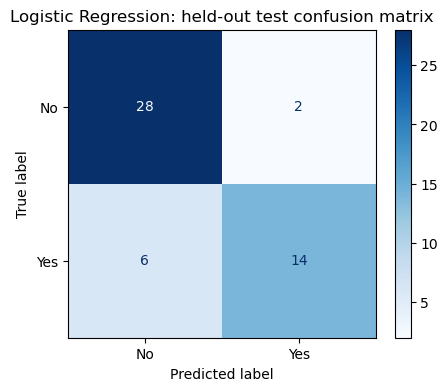

In [9]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, confusion_matrix, precision_score, recall_score
)

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
final_model.fit(X_train, y_train)
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label='Yes', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, pos_label='Yes', zero_division=0)

majority_label = y_train.mode()[0]
majority_test_accuracy = accuracy_score(y_test, [majority_label] * len(y_test))

test_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Yes)', 'Recall (Yes)', 'Majority-class accuracy'],
    'Test score': [test_accuracy, test_precision, test_recall, majority_test_accuracy]
})
display(test_results.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=['No', 'Yes'], cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression: held-out test confusion matrix')
plt.show()


## 9. Error analysis
Classification: false positives/false negatives. Regression: largest residuals.

I will examine false positives (predicted Yes, actual No) and false negatives (predicted No, actual Yes). The feature values can suggest possible reasons for errors, but they do not prove why a student earned a particular score. Other information not included in this dataset could also matter.

In [10]:
error_analysis = X_test.copy()
error_analysis.insert(0, 'student_id', df.loc[X_test.index, 'student_id'])
error_analysis['Actual'] = y_test
error_analysis['Predicted'] = y_test_pred

error_analysis['Error type'] = 'Correct'
error_analysis.loc[(error_analysis['Actual'] == 'No') & (error_analysis['Predicted'] == 'Yes'), 'Error type'] = 'False positive'
error_analysis.loc[(error_analysis['Actual'] == 'Yes') & (error_analysis['Predicted'] == 'No'), 'Error type'] = 'False negative'

false_positives = error_analysis[error_analysis['Error type'] == 'False positive']
false_negatives = error_analysis[error_analysis['Error type'] == 'False negative']

print(f'False positives: {len(false_positives)}')
print(f'False negatives: {len(false_negatives)}')

print('A few false positives:')
display(false_positives.head(3))
print('A few false negatives:')
display(false_negatives.head(3))


False positives: 2
False negatives: 6
A few false positives:


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,Actual,Predicted,Error type
132,S133,9.7,5.7,92.9,13,Some,Yes,0,No,Yes,False positive
169,S170,9.4,7.5,98.3,19,None,No,45,No,Yes,False positive


A few false negatives:


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,Actual,Predicted,Error type
113,S114,10.3,6.0,89.5,9,Some,No,38,Yes,No,False negative
80,S081,5.6,7.6,87.3,36,None,No,28,Yes,No,False negative
140,S141,9.4,7.0,82.8,13,Some,No,31,Yes,No,False negative


The model made 2 false positives and 6 false negatives, so it missed high scorers much more often than it wrongly flagged them (it caught 14 of the 20 "Yes" students). Both false positives had high attendance (92.9 and 98.3) and above-average study hours (about 9.5), so they looked like strong students on paper but still scored under 80. Five of the six false negatives weren't in a study group (compared to about 38% of correctly classified students), and their average attendance was lower (82.2 vs. 85.9 for the correct ones). Two of the false negatives also had missing values that got filled in by the imputer, and one (S081) had 36 practice problems but only 5.6 study hours, so mixed or average-looking habits are probably the hardest cases. These are just hypotheses from 8 mistakes, and the model doesn't tell us why any student scored what they did.

In [11]:
misclassified_students = error_analysis[error_analysis['Error type'].isin(['False positive', 'False negative'])]
display(misclassified_students)

group_order = ['False positive', 'False negative', 'Correct']
numeric_means = error_analysis.groupby('Error type')[numeric_features].mean().reindex(group_order)
study_group_counts = pd.crosstab(error_analysis['Error type'], error_analysis['study_group']).add_prefix('study_group=')
experience_counts = pd.crosstab(error_analysis['Error type'], error_analysis['prior_programming_experience']).add_prefix('prior_programming_experience=')
summary_table = numeric_means.join(study_group_counts).join(experience_counts).reindex(group_order).fillna(0)
display(summary_table)


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,Actual,Predicted,Error type
113,S114,10.3,6.0,89.5,9,Some,No,38,Yes,No,False negative
80,S081,5.6,7.6,87.3,36,None,No,28,Yes,No,False negative
140,S141,9.4,7.0,82.8,13,Some,No,31,Yes,No,False negative
132,S133,9.7,5.7,92.9,13,Some,Yes,0,No,Yes,False positive
37,S038,5.5,7.1,78.3,22,Some,Yes,19,Yes,No,False negative
89,S090,NaN,6.2,72.7,15,Strong,No,28,Yes,No,False negative
99,S100,5.7,7.2,82.7,19,NaN,No,14,Yes,No,False negative
169,S170,9.4,7.5,98.3,19,None,No,45,No,Yes,False positive


,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,commute_minutes,study_group=No,study_group=Yes,prior_programming_experience=None,prior_programming_experience=Some,prior_programming_experience=Strong
Error type,,,,,,,,,,
False positive,9.5500,6.600000,95.600000,16.000000,22.500000,1,1,1,1,0
False negative,7.3000,6.850000,82.216667,19.000000,26.333333,5,1,1,3,1
Correct,7.8575,6.885366,85.914286,17.190476,22.190476,16,26,17,17,7


The problem is that every time I check test accuracy and then change something, the test set is guiding my decisions. The model never trains on it, but I'd be picking whichever model happens to do best on those particular students, so the test set becomes part of model development. That means the final test score is no longer an honest estimate of how it does on new data, because it's biased upward. The second workflow keeps all the experimenting inside the training data with CV and only touches the test set once at the end, so that last score is a fair check.

Scaling helps Logistic Regression because it's fit through optimization with regularization, so features on different scales (attendance in the 70s-90s vs. sleep around 5-8) can affect the coefficients unevenly. Decision Trees don't need it since each split is just a threshold on one feature, like attendance_rate < 85. Standardizing changes that number, but the same students end up on each side. Random Forests are made of many trees, so the same logic applies.

## 9.1. Design One Controlled Experiment

Hypothesis: I expect Logistic Regression's CV accuracy to be about the same with and without StandardScaler, probably within one standard deviation, because the model can compensate for unscaled features by using larger or smaller coefficients. I do expect a small drop without scaling, because the regularization penalty in scikit-learn's Logistic Regression treats features with different scales unequally, so features like commute_minutes and sleep_hours_per_night are penalized differently.

In [12]:
numeric_with_scaling = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
numeric_without_scaling = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_with_scaling = ColumnTransformer([
    ('numeric', numeric_with_scaling, numeric_features),
    ('categorical', categorical_preprocessor, categorical_features)
])
preprocessor_without_scaling = ColumnTransformer([
    ('numeric', numeric_without_scaling, numeric_features),
    ('categorical', categorical_preprocessor, categorical_features)
])

scaler_workflows = {
    'With StandardScaler': Pipeline([
        ('preprocessor', preprocessor_with_scaling),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Without StandardScaler': Pipeline([
        ('preprocessor', preprocessor_without_scaling),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ])
}

scaler_scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label='Yes', zero_division=0),
    'recall': make_scorer(recall_score, pos_label='Yes', zero_division=0)
}

scaler_results = {}
summary_rows = []
for name, workflow in scaler_workflows.items():
    scores = cross_validate(workflow, X_train, y_train, cv=shared_cv, scoring=scaler_scoring)
    scaler_results[name] = scores
    summary_rows.append({
        'Version': name,
        'Mean accuracy': scores['test_accuracy'].mean(),
        'Std accuracy': scores['test_accuracy'].std(),
        'Mean precision (Yes)': scores['test_precision'].mean(),
        'Std precision (Yes)': scores['test_precision'].std(),
        'Mean recall (Yes)': scores['test_recall'].mean(),
        'Std recall (Yes)': scores['test_recall'].std()
    })

scaler_summary = pd.DataFrame(summary_rows).set_index('Version')
display(scaler_summary.round(3))

fold_accuracies = pd.DataFrame({
    name: scores['test_accuracy']
    for name, scores in scaler_results.items()
}, index=[f'Fold {i}' for i in range(1, 6)])
print(fold_accuracies.round(3))


,Mean accuracy,Std accuracy,Mean precision (Yes),Std precision (Yes),Mean recall (Yes),Std recall (Yes)
Version,,,,,,
With StandardScaler,0.740,0.064,0.728,0.143,0.571,0.118
Without StandardScaler,0.745,0.064,0.732,0.144,0.583,0.113


        With StandardScaler  Without StandardScaler
Fold 1                0.725                   0.725
Fold 2                0.650                   0.650
Fold 3                0.850                   0.850
Fold 4                0.750                   0.750
Fold 5                0.725                   0.750


My hypothesis was that accuracy would be about the same with and without scaling, with a small drop without it. With scaling I got 0.740 ± 0.064 and without scaling 0.745 ± 0.064, and precision (0.728 vs. 0.732) and recall (0.571 vs. 0.583) were also nearly identical. The fold scores matched in 4 of 5 folds, and fold 5 differed by one student. So "about the same, within one std" is supported, but the small drop wasn't, since the no-scaling version was slightly higher, though 0.005 is basically nothing. My guess is that the default regularization is mild and the dataset is small, so the feature scales didn't change the fit much, but I'd need to test other settings to say for sure.

Across cross-validation, Logistic Regression looked best (0.740 vs. 0.690 for Random Forest, 0.670 for the depth-4 tree, and 0.605 for the baseline), but the differences were small compared to the fold variation. Depth 4 had the best CV score for the tree, and deeper trees clearly overfit. On the test set, Logistic Regression reached 0.840, well above the 0.600 baseline, though 50 students is a small sample. Overall the habit features carry some signal, but recall (0.70 on test) shows the model still misses a lot of high scorers.

## 10. Conclusion and AI Reflection
Summarize your evidence. Describe one AI suggestion you rejected or modified and why.

What I asked: I gave my AI agent the starter notebook and asked it to fill it in section by section for the classification track. I told it up front not to use the test set for choosing anything, to use one shared 5-fold CV for every model, and to keep "None" as a real category when loading the CSV (keep_default_na=False), since pandas was turning it into a missing value. I also asked it to explain the difference between a parameter and a hyperparameter using max_depth. 

What it recommended and whether I accepted it: It built the preprocessing pipeline, the model comparison table, the depth experiment, and the plot, and I accepted the code after checking it. It wrote the depth-4 conclusion as "generalizes best" without mentioning that the CV curve is bumpy and the gaps are close to the fold std. I didn't keep that wording, and I noted the uncertainty in my own writeup. I also noticed that my "tuned" tree was the same as the original depth-4 tree, so that comparison row is identical.

How I verified it: I searched the notebook to make sure X_test and y_test were only used in the split, the final evaluation, and the error analysis. I checked that the results agreed with each other (2 false positives and 6 false negatives out of 50 gives 0.84 accuracy, which matches the report). I also had a second AI review the notebook and flag problems. 

What I changed: I wrote my own hypothesis before the scaling experiment ran, and had the agent write only the code for it. 

What I learned: Training accuracy always goes up as the tree gets deeper, but CV accuracy doesn't, so training accuracy alone is a bad way to pick a model. Also, a difference between two models that's smaller than the fold std isn't strong evidence. My scaling hypothesis was partly wrong, which showed me that "scaling matters" isn't a universal rule.

Did the AI suggest using the test set to compare or tune models? No, the AI didn't suggest using test set to compare or tune models. It did that becuase I specifially told it not to. In my notebook the model choice was made only from CV results, and the test set was used once. My earlier notebook had scored the baseline on the test set, so I told the agent to use CV on the training data instead.

**Link to the AI Agent Chat:**: https://chatgpt.com/s/cx_6ac6b5f277748191a70ddd30bff3bae9